# Restaurant Revenue Prediction

**Author:** Nour Eldin Islam
Dataset:https://www.kaggle.com/datasets/mrsimple07/restaurants-revenue-prediction/data

## Objective

The objective of this project is to predict a restaurant's monthly revenue using machine learning techniques.

The project follows the complete machine learning pipeline:
- Data understanding
- Data cleaning
- Exploratory Data Analysis
- Feature Engineering
- Model Training
- Model Evaluation
- Business Insights


In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Load Dataset

Load the restaurant revenue dataset and inspect its basic structure.

In [32]:
df = pd.read_csv("Restaurant_revenue .csv")

df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121


## Dataset Overview

Let's inspect the dataset to understand the available features and identify potential issues.

In [10]:
df.info()

df.describe()

df.shape

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Cuisine_Type               1000 non-null   str    
 4   Average_Customer_Spending  1000 non-null   float64
 5   Promotions                 1000 non-null   int64  
 6   Reviews                    1000 non-null   int64  
 7   Monthly_Revenue            1000 non-null   float64
dtypes: float64(4), int64(3), str(1)
memory usage: 62.6 KB


(1000, 8)

In [6]:
df.duplicated().sum()

np.int64(0)

### Distribution of Monthly Revenue

Understanding the distribution helps identify skewness and potential outliers.

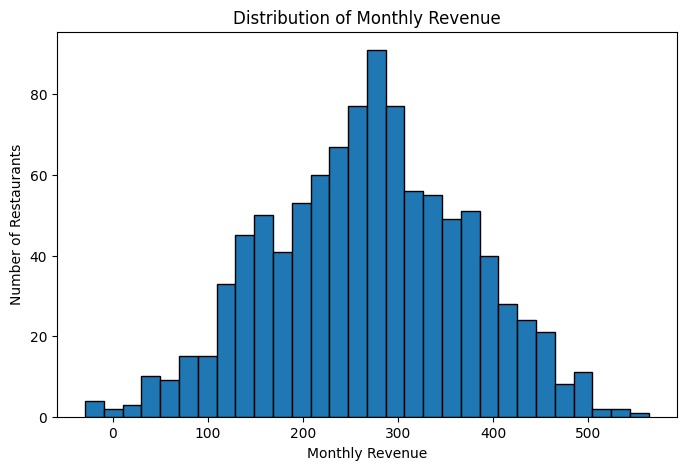

In [13]:
plt.figure(figsize=(8,5))
plt.hist(df["Monthly_Revenue"], bins=30, edgecolor="black")

plt.title("Distribution of Monthly Revenue")
plt.xlabel("Monthly Revenue")
plt.ylabel("Number of Restaurants")

plt.show()

The distribution of monthly revenue is approximately symmetric and bell-shaped.
 Most restaurants have monthly revenue around 250–300, while relatively few restaurants have very low or very high monthly revenue.
 No strong skewness is observed.

## Dataset Description

The dataset contains information about restaurants and their business characteristics.
The goal is to predict the **Monthly Revenue** of a restaurant based on these features.

| Feature | Data Type | Description |
|---------|-----------|-------------|
| Number_of_Customers | Integer | Number of customers visiting the restaurant. |
| Menu_Price | Float | Average price of items on the restaurant's menu. |
| Marketing_Spend | Float | Amount spent on marketing and advertising. |
| Cuisine_Type | Categorical | Type of cuisine served (e.g., Italian, Japanese, Mexican). |
| Average_Customer_Spending | Float | Average amount spent by each customer. |
| Promotions | Integer (0/1) | Indicates whether promotions or discounts were active. |
| Reviews | Integer | Customer review score or review count provided in the dataset. |
| Monthly_Revenue | Float | **Target variable:** the restaurant's monthly revenue. |


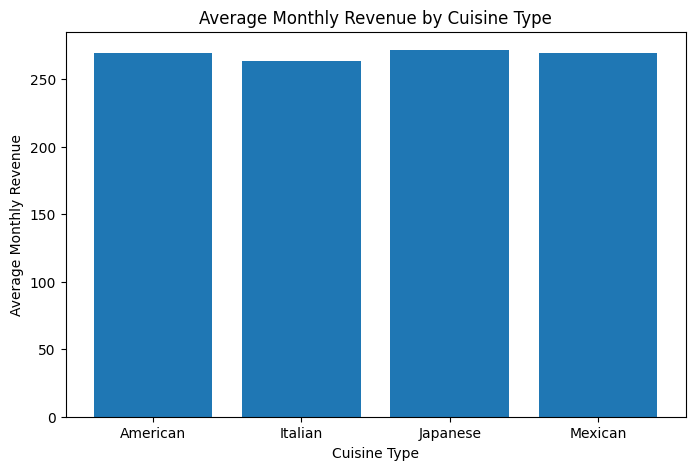

Cuisine_Type
Japanese    271.700186
American    269.604825
Mexican     269.366082
Italian     263.699862
Name: Monthly_Revenue, dtype: float64


In [22]:
avg_revenue = df.groupby("Cuisine_Type")["Monthly_Revenue"].mean()

plt.figure(figsize=(8,5))
plt.bar(avg_revenue.index, avg_revenue.values)

plt.title("Average Monthly Revenue by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Monthly Revenue")

plt.show()

avg_revenue = df.groupby("Cuisine_Type")["Monthly_Revenue"].mean()

print(avg_revenue.sort_values(ascending=False))

Japanese restaurants have the highest average monthly revenue in this dataset, while Indian restaurants have the lowest. This suggests that cuisine type may influence restaurant revenue and should be considered an important feature in the predictive model.

## Data Preprocessing

The dataset contains one categorical feature, `Cuisine_Type`. Since Linear Regression works with numerical features, this variable is converted into a numerical representation during preprocessing before training the model.

In [33]:
df = pd.get_dummies(df, columns=["Cuisine_Type"], drop_first=True)

In [34]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue,Cuisine_Type_Italian,Cuisine_Type_Japanese,Cuisine_Type_Mexican
0,61,43.117635,12.663793,36.236133,0,45,350.912040,False,True,False
1,24,40.020077,4.577892,17.952562,0,36,221.319091,True,False,False
2,81,41.981485,4.652911,22.600420,1,91,326.529763,False,True,False
3,70,43.005307,4.416053,18.984098,1,59,348.190573,True,False,False
4,30,17.456199,3.475052,12.766143,1,30,185.009121,True,False,False
